# 10 — Gene-Level Analysis

**Question**: Which blood genes drive prediction, and are they shared or unique across tissues and pathologies?

We load per-fold RF feature importances from NB07, build consensus gene sets,
then examine overlap patterns across tissues and pathologies.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from itertools import combinations
from gtex_biomarkers.config import Config

Config.ensure_dirs()

# Load feature importances from NB07
df_agg = pd.read_csv(Config.TABLES_DIR / "rf_feature_importances.csv")
df_detail = pd.read_csv(Config.TABLES_DIR / "rf_selected_features.csv")
rf_summary = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")

# Ensembl → gene symbol mapping from GCT header
gct_path = Config.RAW_DIR / "GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct"
gct_head = pd.read_csv(gct_path, sep="\t", skiprows=2, nrows=0, usecols=[0, 1],
                        names=["ensembl", "symbol"], header=0)
# Read just the two ID columns
gene_map_df = pd.read_csv(gct_path, sep="\t", skiprows=2, usecols=[0, 1])
gene_map_df.columns = ["ensembl", "symbol"]
gene_map = dict(zip(gene_map_df["ensembl"], gene_map_df["symbol"]))

# Add symbol column to aggregated table
df_agg["symbol"] = df_agg["gene"].map(gene_map)
print(f"Loaded {len(df_agg):,} aggregated feature entries")
print(f"Mapped {df_agg['symbol'].notna().sum():,} / {len(df_agg):,} to gene symbols")
print(f"Models: {df_agg[['tissue','category']].drop_duplicates().shape[0]}")

Loaded 16,163 aggregated feature entries
Mapped 16,163 / 16,163 to gene symbols
Models: 53


## 10.1 — Consensus Gene Sets & Importance Landscape

For each tissue × pathology pair, identify **consensus genes** — selected in ≥ 3 of 5 CV folds.
These are the stable predictive features, not noise from a single train split.

Consensus genes per model:
  Mean:   51
  Median: 50
  Range:  26 – 82


/var/folders/bv/6z9_9t8j4m10s0k827gq9bhr0000gn/T/ipykernel_69709/167080619.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conc = consensus.groupby(["tissue", "category"]).apply(importance_concentration)


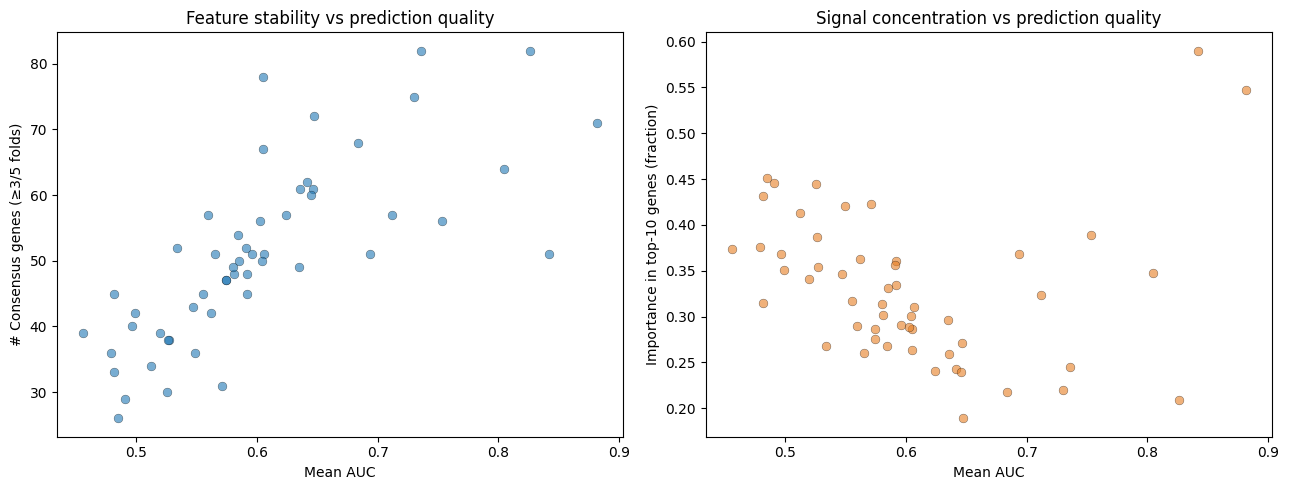

,tissue,category,n_consensus_genes,mean_auc
17,Breast - Mammary Tissue,gynecomastoid,71,0.881665
15,Breast - Mammary Tissue,atrophy,51,0.841520
47,Spleen,congestion,82,0.826177
27,Liver,cirrhosis,64,0.804298
18,Breast - Mammary Tissue,hyperplasia,56,0.752899
39,Lung,pneumonia,82,0.736086
45,Pancreas,saponification,75,0.730258
48,Testis,spermatogenesis,57,0.711798
40,Muscle - Skeletal,atrophy,51,0.693750
28,Liver,congestion,68,0.683426


In [4]:
# Consensus = selected in >= 3/5 folds
consensus = df_agg[df_agg["n_folds_selected"] >= 3].copy()

# Count consensus genes per model
cons_per_model = (
    consensus.groupby(["tissue", "category"])
    .size()
    .reset_index(name="n_consensus_genes")
    .merge(rf_summary[["tissue", "category", "mean_auc"]], on=["tissue", "category"])
    .sort_values("mean_auc", ascending=False)
)

print(f"Consensus genes per model:")
print(f"  Mean:   {cons_per_model['n_consensus_genes'].mean():.0f}")
print(f"  Median: {cons_per_model['n_consensus_genes'].median():.0f}")
print(f"  Range:  {cons_per_model['n_consensus_genes'].min()} – {cons_per_model['n_consensus_genes'].max()}")

# Top-10 genes per pair (by mean importance), with symbols
top10_per_pair = (
    consensus.sort_values(["tissue", "category", "mean_importance"], ascending=[True, True, False])
    .groupby(["tissue", "category"])
    .head(10)
    [["tissue", "category", "gene", "symbol", "mean_importance", "n_folds_selected"]]
)
top10_per_pair.to_csv(Config.TABLES_DIR / "rf_top10_genes_per_pair.csv", index=False)

# Importance concentration: what fraction of total importance is in top-10?
def importance_concentration(grp):
    total = grp["mean_importance"].sum()
    top10 = grp.nlargest(10, "mean_importance")["mean_importance"].sum()
    return top10 / total if total > 0 else 0

conc = consensus.groupby(["tissue", "category"]).apply(importance_concentration)
conc = conc.reset_index(name="top10_frac")
conc = conc.merge(rf_summary[["tissue", "category", "mean_auc"]], on=["tissue", "category"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: consensus gene count vs AUC
ax = axes[0]
ax.scatter(cons_per_model["mean_auc"], cons_per_model["n_consensus_genes"],
           alpha=0.6, s=40, edgecolors="black", lw=0.3)
ax.set_xlabel("Mean AUC"); ax.set_ylabel("# Consensus genes (≥3/5 folds)")
ax.set_title("Feature stability vs prediction quality")

# Right: importance concentration vs AUC
ax = axes[1]
ax.scatter(conc["mean_auc"], conc["top10_frac"],
           alpha=0.6, s=40, edgecolors="black", lw=0.3, color="#e67e22")
ax.set_xlabel("Mean AUC"); ax.set_ylabel("Importance in top-10 genes (fraction)")
ax.set_title("Signal concentration vs prediction quality")

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "feature_stability_landscape.pdf", bbox_inches="tight")
plt.show()

display(cons_per_model.head(15))

## 10.2 — Cross-Tissue Gene Overlap (Shared Pathologies)

Several pathologies appear in multiple tissues: fibrosis (7), congestion (3),
sclerotic (4), atherosis (3), calcification (3), atherosclerosis (3), atrophy (3).

For each shared pathology: do different tissues use the **same** blood genes, or completely different ones?

Shared pathologies (≥2 tissues): 8
  atherosclerosis: 3 tissues
  atherosis: 3 tissues
  atrophy: 3 tissues
  calcification: 3 tissues
  congestion: 3 tissues
  fibrosis: 10 tissues
  hyperplasia: 2 tissues
  sclerotic: 4 tissues


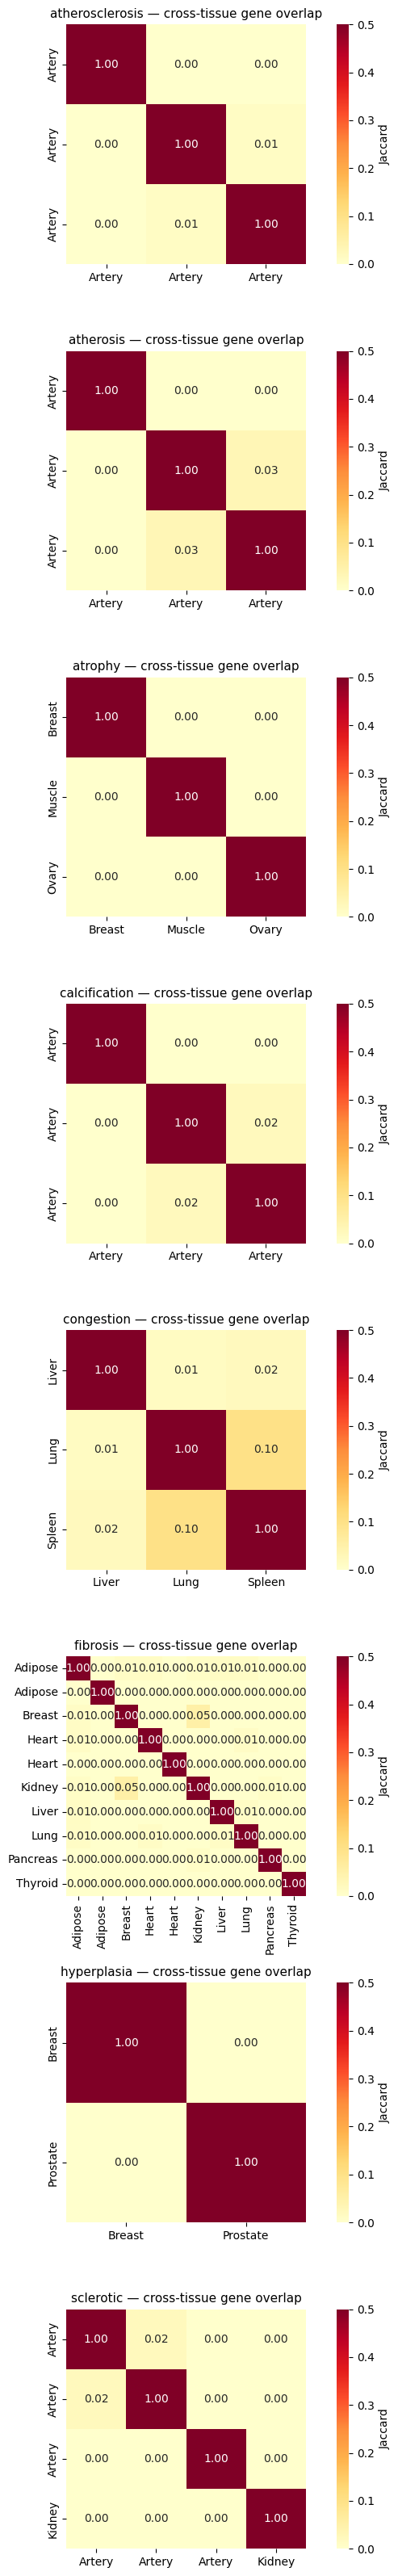


Mean Jaccard across all cross-tissue pairs: 0.005
Max Jaccard: 0.100


,pathology,tissue_a,tissue_b,jaccard,shared_genes,union_genes
14,congestion,Lung,Spleen,0.100000,14,140
34,fibrosis,Breast - Mammary Tissue,Kidney - Cortex,0.053097,6,113
5,atherosis,Artery - Coronary,Artery - Tibial,0.031915,3,94
11,calcification,Artery - Coronary,Artery - Tibial,0.022222,2,90
61,sclerotic,Artery - Aorta,Artery - Coronary,0.021898,3,137
13,congestion,Liver,Spleen,0.020408,3,147
12,congestion,Liver,Lung,0.014493,2,138
2,atherosclerosis,Artery - Coronary,Artery - Tibial,0.013514,1,74
20,fibrosis,Adipose - Subcutaneous,Liver,0.012346,1,81
54,fibrosis,Liver,Lung,0.011628,1,86


In [5]:
def jaccard(set_a, set_b):
    """Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

# Build consensus gene sets per (tissue, category)
gene_sets = (
    consensus.groupby(["tissue", "category"])["gene"]
    .apply(set)
    .to_dict()
)

# Find pathologies that appear in >= 2 tissues
cat_tissue_count = consensus.groupby("category")["tissue"].nunique()
shared_cats = cat_tissue_count[cat_tissue_count >= 2].index.tolist()
print(f"Shared pathologies (≥2 tissues): {len(shared_cats)}")
for cat in sorted(shared_cats):
    tissues = consensus[consensus["category"] == cat]["tissue"].unique()
    print(f"  {cat}: {len(tissues)} tissues")

# Compute Jaccard matrices per shared pathology
fig_rows = len(shared_cats)
fig, axes = plt.subplots(fig_rows, 1, figsize=(8, 4 * fig_rows))
if fig_rows == 1:
    axes = [axes]

cross_tissue_results = []

for idx, cat in enumerate(sorted(shared_cats)):
    # Get all (tissue, cat) pairs for this pathology
    pairs = [(t, cat) for (t, c) in gene_sets if c == cat]
    pairs = sorted(pairs, key=lambda x: x[0])

    if len(pairs) < 2:
        continue

    tissues = [t for t, _ in pairs]
    n = len(tissues)
    jac_mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            s_i = gene_sets.get(pairs[i], set())
            s_j = gene_sets.get(pairs[j], set())
            jac_mat[i, j] = jaccard(s_i, s_j)
            if i < j:
                cross_tissue_results.append({
                    "pathology": cat,
                    "tissue_a": tissues[i], "tissue_b": tissues[j],
                    "jaccard": jac_mat[i, j],
                    "shared_genes": len(s_i & s_j),
                    "union_genes": len(s_i | s_j),
                })

    # Shorten tissue names for display
    short = [t.split(" - ")[0][:15] for t in tissues]
    ax = axes[idx]
    sns.heatmap(jac_mat, annot=True, fmt=".2f", xticklabels=short, yticklabels=short,
                cmap="YlOrRd", vmin=0, vmax=0.5, ax=ax, square=True,
                cbar_kws={"label": "Jaccard"})
    ax.set_title(f"{cat} — cross-tissue gene overlap", fontsize=11)

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "cross_tissue_gene_overlap.pdf", bbox_inches="tight")
plt.show()

df_cross = pd.DataFrame(cross_tissue_results)
df_cross.to_csv(Config.TABLES_DIR / "cross_tissue_gene_overlap.csv", index=False)
print(f"\nMean Jaccard across all cross-tissue pairs: {df_cross['jaccard'].mean():.3f}")
print(f"Max Jaccard: {df_cross['jaccard'].max():.3f}")
display(df_cross.sort_values("jaccard", ascending=False).head(10))

## 10.3 — Within-Tissue Gene Overlap (Multiple Pathologies)

For tissues with many pathologies (Lung: 9, Artery-Tibial: 5, Liver: 4, Breast: 4):
do different pathologies within the same tissue share predictive genes?

Tissues with ≥3 pathologies: 10


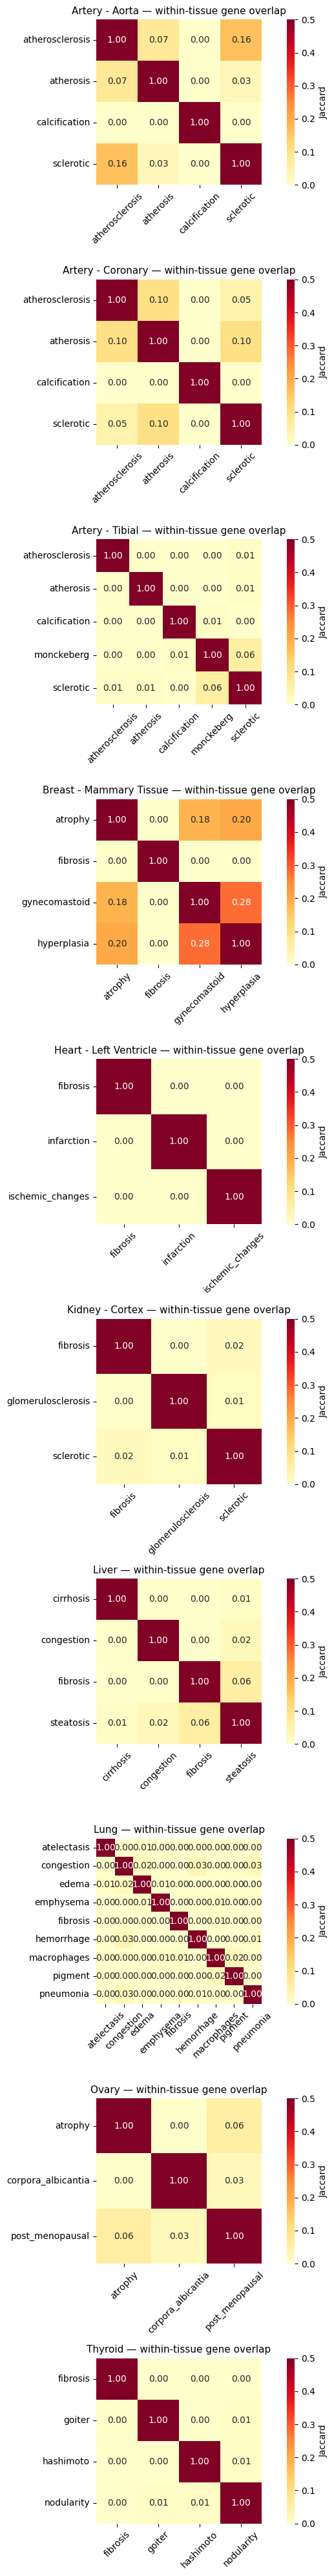


Mean Jaccard within-tissue: 0.019


,tissue,category_a,category_b,jaccard,shared_genes,union_genes
27,Breast - Mammary Tissue,gynecomastoid,hyperplasia,0.282828,28,99
24,Breast - Mammary Tissue,atrophy,hyperplasia,0.202247,18,89
23,Breast - Mammary Tissue,atrophy,gynecomastoid,0.184466,19,103
2,Artery - Aorta,atherosclerosis,sclerotic,0.163793,19,116
10,Artery - Coronary,atherosis,sclerotic,0.101124,9,89
6,Artery - Coronary,atherosclerosis,atherosis,0.100000,6,60
0,Artery - Aorta,atherosclerosis,atherosis,0.075000,6,80
39,Liver,fibrosis,steatosis,0.058824,5,85
77,Ovary,atrophy,post_menopausal,0.057471,5,87
21,Artery - Tibial,monckeberg,sclerotic,0.056604,6,106


In [6]:
# Tissues with >= 3 pathologies
tissue_cat_count = consensus.groupby("tissue")["category"].nunique()
multi_tissues = tissue_cat_count[tissue_cat_count >= 3].index.tolist()
print(f"Tissues with ≥3 pathologies: {len(multi_tissues)}")

within_tissue_results = []

n_plots = len(multi_tissues)
fig, axes = plt.subplots(n_plots, 1, figsize=(8, 4 * n_plots))
if n_plots == 1:
    axes = [axes]

for idx, tissue in enumerate(sorted(multi_tissues)):
    # Get all categories for this tissue
    pairs = [(tissue, c) for (t, c) in gene_sets if t == tissue]
    pairs = sorted(pairs, key=lambda x: x[1])

    if len(pairs) < 2:
        continue

    cats = [c for _, c in pairs]
    n = len(cats)
    jac_mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            s_i = gene_sets.get(pairs[i], set())
            s_j = gene_sets.get(pairs[j], set())
            jac_mat[i, j] = jaccard(s_i, s_j)
            if i < j:
                within_tissue_results.append({
                    "tissue": tissue,
                    "category_a": cats[i], "category_b": cats[j],
                    "jaccard": jac_mat[i, j],
                    "shared_genes": len(s_i & s_j),
                    "union_genes": len(s_i | s_j),
                })

    ax = axes[idx]
    sns.heatmap(jac_mat, annot=True, fmt=".2f", xticklabels=cats, yticklabels=cats,
                cmap="YlOrRd", vmin=0, vmax=0.5, ax=ax, square=True,
                cbar_kws={"label": "Jaccard"})
    ax.set_title(f"{tissue} — within-tissue gene overlap", fontsize=11)
    ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "within_tissue_gene_overlap.pdf", bbox_inches="tight")
plt.show()

df_within = pd.DataFrame(within_tissue_results)
df_within.to_csv(Config.TABLES_DIR / "within_tissue_gene_overlap.csv", index=False)
print(f"\nMean Jaccard within-tissue: {df_within['jaccard'].mean():.3f}")
display(df_within.sort_values("jaccard", ascending=False).head(10))

## 10.4 — Universal vs Tissue-Specific Genes

Across all 53 models: which genes appear in many models (pan-predictive)
vs only one (disease-specific)?

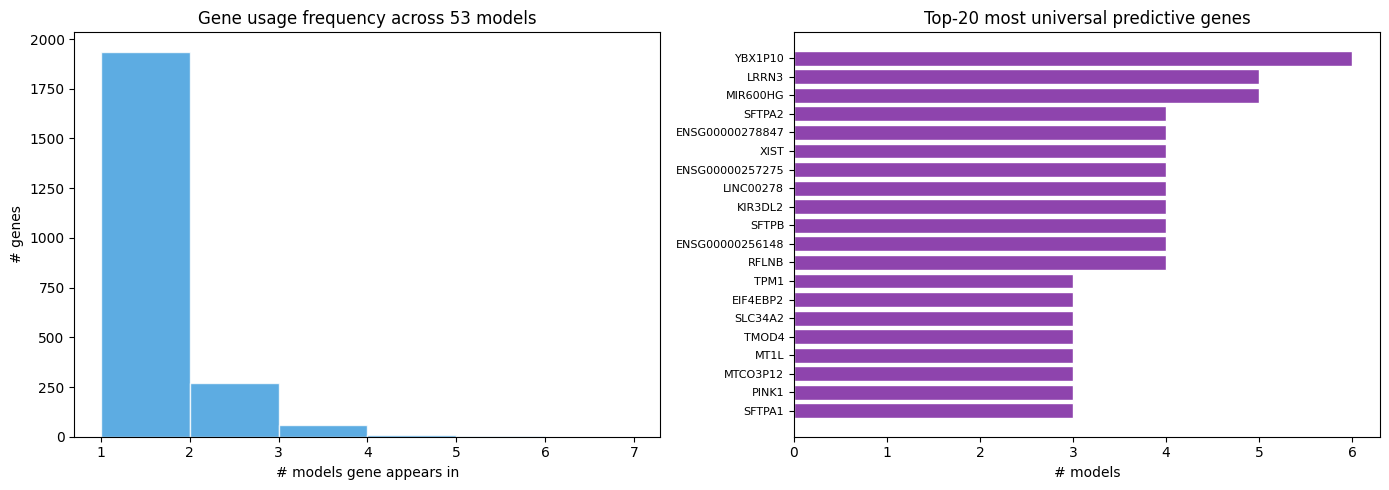

Total unique consensus genes: 2,275
Genes in only 1 model: 1,937 (85%)
Genes in ≥10 models: 0


,gene,n_models,symbol
1432,ENSG00000213866.3,6,YBX1P10
1052,ENSG00000173114.13,5,LRRN3
1647,ENSG00000236901.6,5,MIR600HG
1218,ENSG00000185303.17,4,SFTPA2
2107,ENSG00000278847.1,4,ENSG00000278847
1564,ENSG00000229807.13,4,XIST
1829,ENSG00000257275.6,4,ENSG00000257275
1579,ENSG00000231535.8,4,LINC00278
1686,ENSG00000240403.5,4,KIR3DL2
998,ENSG00000168878.19,4,SFTPB


In [7]:
# Count how many models each gene appears in (consensus only)
gene_model_count = (
    consensus.groupby("gene")[["tissue", "category"]]
    .apply(lambda g: len(g.drop_duplicates()))
    .reset_index(name="n_models")
)
gene_model_count["symbol"] = gene_model_count["gene"].map(gene_map)
gene_model_count = gene_model_count.sort_values("n_models", ascending=False)

# Frequency histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(gene_model_count["n_models"], bins=range(1, gene_model_count["n_models"].max() + 2),
        color="#3498db", edgecolor="white", alpha=0.8)
ax.set_xlabel("# models gene appears in")
ax.set_ylabel("# genes")
ax.set_title("Gene usage frequency across 53 models")

# Top-20 most universal genes
top20_universal = gene_model_count.head(20)
ax = axes[1]
labels = [f"{row['symbol']}" if pd.notna(row['symbol']) else row['gene'][:15]
          for _, row in top20_universal.iterrows()]
ax.barh(range(len(top20_universal)), top20_universal["n_models"].values,
        color="#8e44ad", edgecolor="white")
ax.set_yticks(range(len(top20_universal)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("# models")
ax.set_title("Top-20 most universal predictive genes")
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(Config.FIGURES_DIR / "gene_universality.pdf", bbox_inches="tight")
plt.show()

# Summary stats
n_unique_only = (gene_model_count["n_models"] == 1).sum()
n_universal = (gene_model_count["n_models"] >= 10).sum()
print(f"Total unique consensus genes: {len(gene_model_count):,}")
print(f"Genes in only 1 model: {n_unique_only:,} ({n_unique_only/len(gene_model_count)*100:.0f}%)")
print(f"Genes in ≥10 models: {n_universal:,}")

gene_model_count.to_csv(Config.TABLES_DIR / "gene_universality.csv", index=False)
display(top20_universal.head(20))

## 10.5 — Summary: Gene Sharing Heatmap

Clustered heatmap: rows = consensus genes that appear in ≥ 5 models,
columns = tissue × pathology pairs (Easy + Moderate only). Shows which genes
are shared across models vs unique to specific predictions.

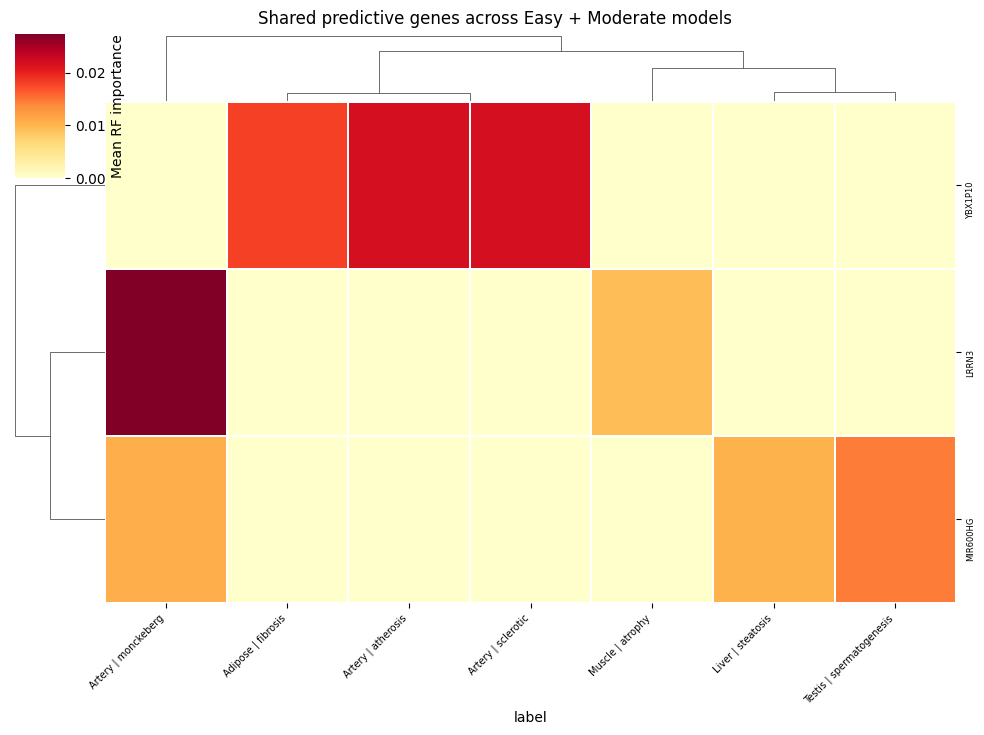

Heatmap: 3 genes × 7 models

SUMMARY
Cross-tissue overlap (same pathology, different tissue):
  Mean Jaccard = 0.005
Within-tissue overlap (same tissue, different pathology):
  Mean Jaccard = 0.019
Unique consensus genes: 2,275
Pan-predictive (≥10 models): 0
Disease-specific (1 model only): 1937


In [8]:
# Focus on Easy + Moderate pairs (AUC >= 0.60)
good_pairs = rf_summary[rf_summary["mean_auc"] >= 0.60][["tissue", "category"]]
good_pairs["label"] = good_pairs["tissue"].str.split(" - ").str[0] + " | " + good_pairs["category"]

# Genes appearing in >= 5 models overall
frequent_genes = gene_model_count[gene_model_count["n_models"] >= 5]["gene"].tolist()

# Build presence/importance matrix
consensus_good = consensus.merge(good_pairs[["tissue", "category", "label"]], on=["tissue", "category"])
consensus_good = consensus_good[consensus_good["gene"].isin(frequent_genes)]

if len(consensus_good) > 0 and len(frequent_genes) > 0:
    pivot = consensus_good.pivot_table(
        index="gene", columns="label", values="mean_importance", fill_value=0
    )

    # Replace gene IDs with symbols for display
    pivot.index = [gene_map.get(g, g[:15]) for g in pivot.index]

    # Cluster
    g = sns.clustermap(
        pivot, cmap="YlOrRd", figsize=(max(10, len(pivot.columns) * 0.5),
                                        max(8, len(pivot) * 0.25)),
        xticklabels=True, yticklabels=True,
        linewidths=0.2, linecolor="white",
        cbar_kws={"label": "Mean RF importance"},
        dendrogram_ratio=(0.1, 0.12),
    )
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7, rotation=45, ha="right")
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
    g.fig.suptitle("Shared predictive genes across Easy + Moderate models", y=1.01, fontsize=12)
    g.savefig(Config.FIGURES_DIR / "gene_sharing_clustermap.pdf", bbox_inches="tight")
    plt.show()
    print(f"Heatmap: {pivot.shape[0]} genes × {pivot.shape[1]} models")
else:
    print("Not enough frequent genes across good models for heatmap — "
          "try lowering the threshold.")

# Final cross vs within summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
if len(df_cross) > 0:
    print(f"Cross-tissue overlap (same pathology, different tissue):")
    print(f"  Mean Jaccard = {df_cross['jaccard'].mean():.3f}")
if len(df_within) > 0:
    print(f"Within-tissue overlap (same tissue, different pathology):")
    print(f"  Mean Jaccard = {df_within['jaccard'].mean():.3f}")
print(f"Unique consensus genes: {len(gene_model_count):,}")
print(f"Pan-predictive (≥10 models): {(gene_model_count['n_models'] >= 10).sum()}")
print(f"Disease-specific (1 model only): {(gene_model_count['n_models'] == 1).sum()}")